# Malaria Target Analysis — Yaoundé (2019–2022)
## Case evolution, the risk threshold, and climate–malaria relationships

Completes the exploratory analysis for Yaoundé by visualizing the **prediction
target** (malaria cases / incidence) and the **75th-percentile risk threshold**,
together with the relationship between climate and malaria that motivates the
modelling. Figures produced:

1. Monthly malaria cases and incidence per Yaoundé district
2. Incidence with the regional risk threshold drawn, showing Low/High months
3. Target distribution and the threshold (histogram + boxplot)
4. Climate–malaria overlay (incidence vs rainfall, with lag)
5. Correlation of malaria incidence with climate variables at several lags
6. Seasonal case cycle


## 0 · Setup & data

In [1]:
import sys; sys.path.insert(0,'/home/claude')
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import seaborn as sns
warnings.filterwarnings('ignore')
from pipeline_lib import build
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150,'axes.titlesize':12,'axes.labelsize':10,'font.size':10})

df = build()
YDE = ['Biyem Assi','Efoulan','Nkolndongo']
sub = df[df['district'].isin(YDE)].copy().sort_values(['district','date'])
THR = sub['threshold_75'].iloc[0]   # Centre region 75th-pct incidence threshold
DCOL = {'Biyem Assi':'#e74c3c','Efoulan':'#2980b9','Nkolndongo':'#27ae60'}
print(f'Yaoundé districts: {YDE}')
print(f'Centre-region threshold (75th pct incidence): {THR:.2f} per 1000')
print(f'High district-months: {int(sub.high.sum())}/{len(sub)}')


Yaoundé districts: ['Biyem Assi', 'Efoulan', 'Nkolndongo']
Centre-region threshold (75th pct incidence): 14.28 per 1000
High district-months: 18/114


## 1 · Monthly malaria cases and incidence per district

The raw case counts reflect district population; the incidence rate normalizes by
population and is the quantity on which the risk class is defined.


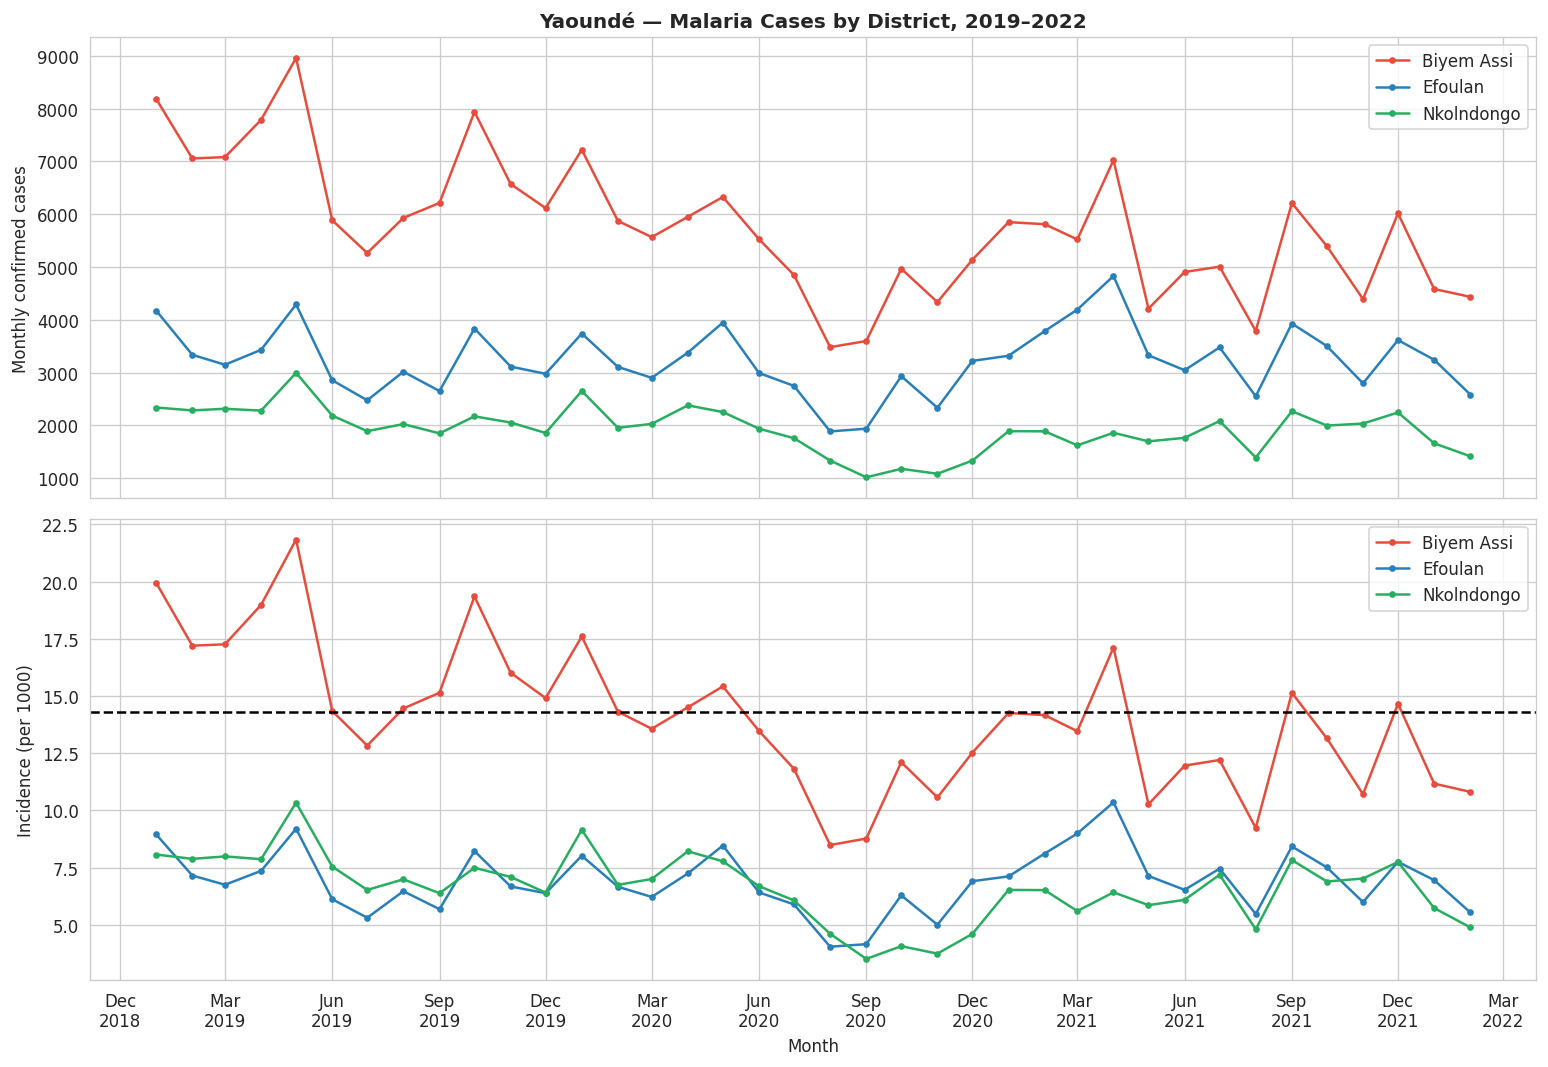

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for d in YDE:
    s = sub[sub.district==d]
    axes[0].plot(s.date, s.cases, '-o', ms=3, color=DCOL[d], label=d)
    axes[1].plot(s.date, s.incidence_rate, '-o', ms=3, color=DCOL[d], label=d)
axes[0].set_ylabel('Monthly confirmed cases'); axes[0].set_title('Yaoundé — Malaria Cases by District, 2019–2022', fontweight='bold'); axes[0].legend()
axes[1].set_ylabel('Incidence (per 1000)'); axes[1].legend()
axes[1].axhline(THR, color='black', ls='--', lw=1.5, label=f'threshold = {THR:.1f}')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[1].set_xlabel('Month')
plt.tight_layout(); plt.savefig('yde_target_districts.png', bbox_inches='tight'); plt.show()


## 2 · Incidence with the risk threshold — Low vs High months

This is the core target figure: the per-district incidence with the regional
75th-percentile threshold drawn. Points above the line are the **High-risk**
district-months the classifier must predict.


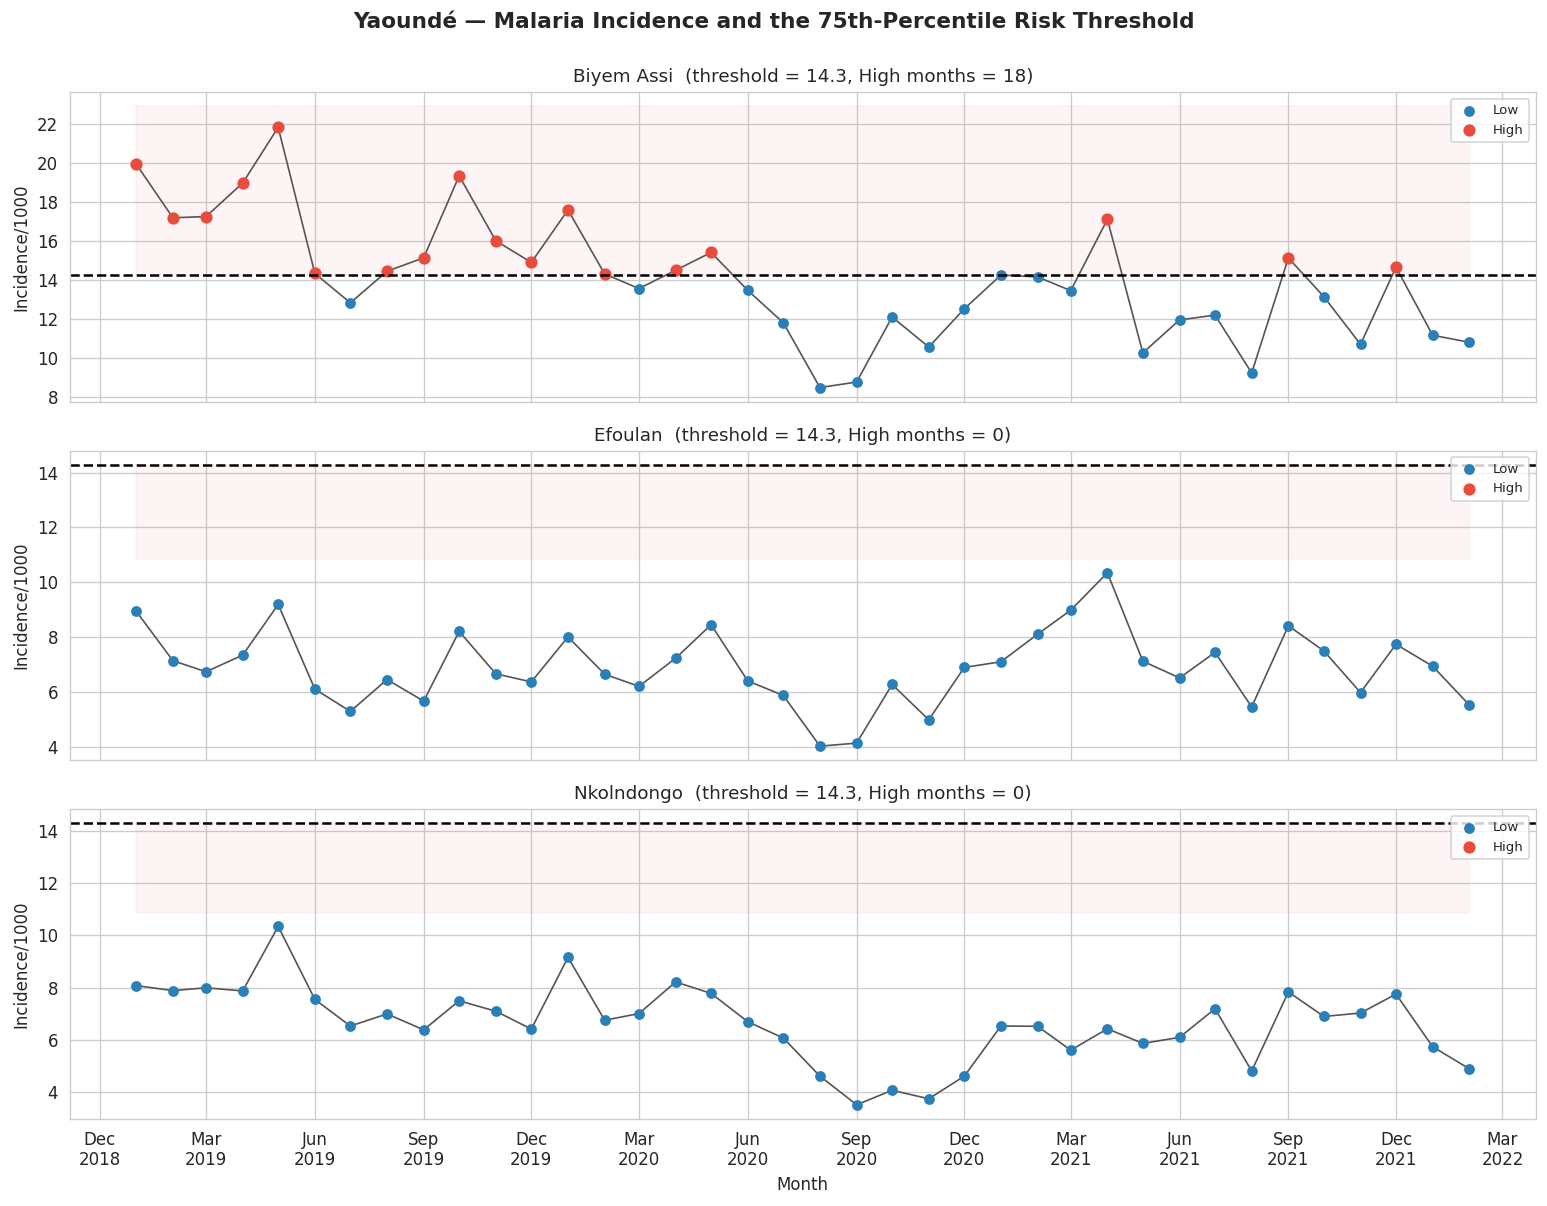

Biyem Assi carries most of the High months; the threshold is regional (Centre).


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, d in zip(axes, YDE):
    s = sub[sub.district==d]
    high = s.incidence_rate > THR
    ax.plot(s.date, s.incidence_rate, '-', color='#555', lw=1, zorder=1)
    ax.scatter(s.date[~high], s.incidence_rate[~high], color='#2980b9', s=30, label='Low', zorder=2)
    ax.scatter(s.date[high], s.incidence_rate[high], color='#e74c3c', s=40, label='High', zorder=2)
    ax.axhline(THR, color='black', ls='--', lw=1.5)
    ax.fill_between(s.date, THR, s.incidence_rate.max()*1.05, color='#e74c3c', alpha=0.05)
    ax.set_ylabel('Incidence/1000'); ax.set_title(f'{d}  (threshold = {THR:.1f}, High months = {int(high.sum())})', fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].set_xlabel('Month')
plt.suptitle('Yaoundé — Malaria Incidence and the 75th-Percentile Risk Threshold', fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig('yde_target_threshold.png', bbox_inches='tight'); plt.show()
print('Biyem Assi carries most of the High months; the threshold is regional (Centre).')


## 3 · Target distribution and the threshold

Where the threshold sits relative to the distribution of incidence, justifying the
75th-percentile choice (it isolates the upper quartile rather than rare extremes).


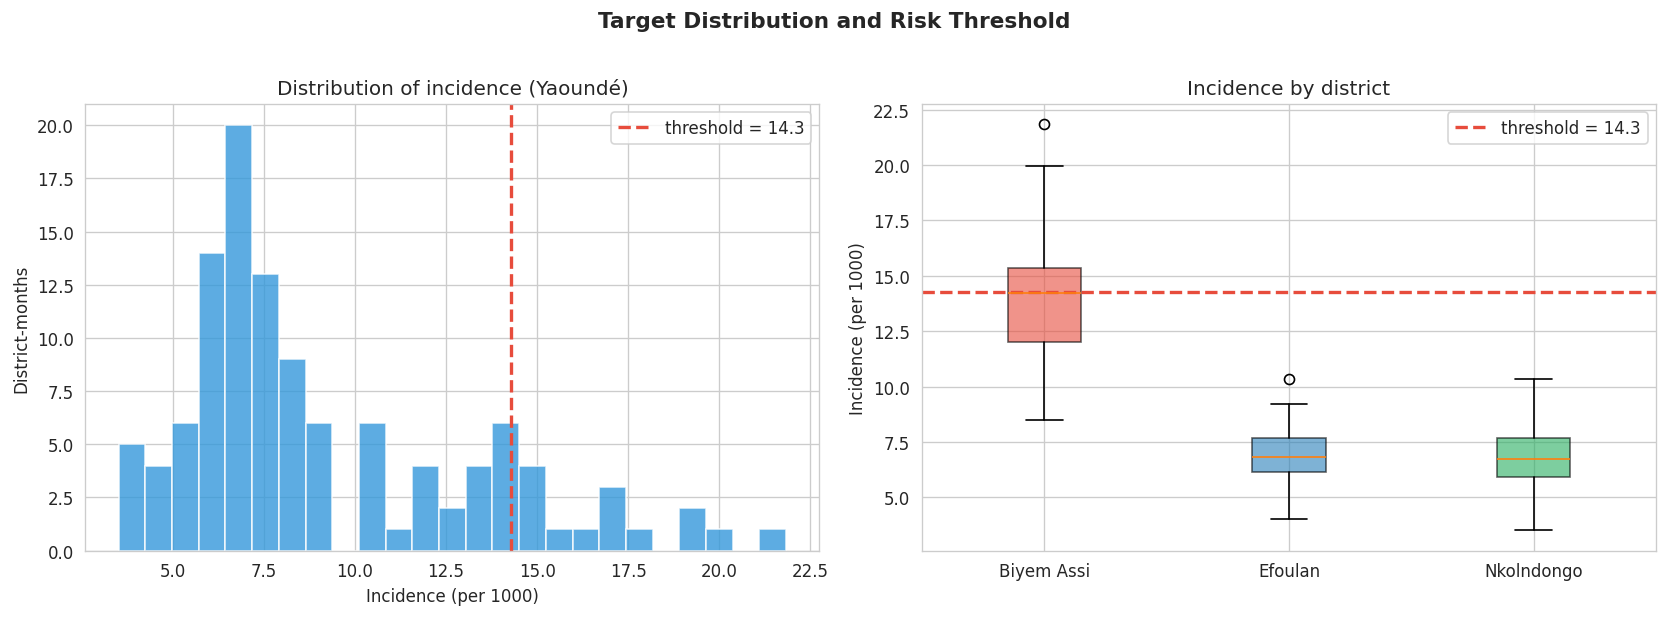

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sub.incidence_rate, bins=25, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(THR, color='#e74c3c', ls='--', lw=2, label=f'threshold = {THR:.1f}')
axes[0].set_xlabel('Incidence (per 1000)'); axes[0].set_ylabel('District-months'); axes[0].set_title('Distribution of incidence (Yaoundé)'); axes[0].legend()
# boxplot per district with threshold
data = [sub[sub.district==d].incidence_rate.values for d in YDE]
bp = axes[1].boxplot(data, labels=YDE, patch_artist=True)
for patch,d in zip(bp['boxes'],YDE): patch.set_facecolor(DCOL[d]); patch.set_alpha(0.6)
axes[1].axhline(THR, color='#e74c3c', ls='--', lw=2, label=f'threshold = {THR:.1f}')
axes[1].set_ylabel('Incidence (per 1000)'); axes[1].set_title('Incidence by district'); axes[1].legend()
plt.suptitle('Target Distribution and Risk Threshold', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('yde_target_distribution.png', bbox_inches='tight'); plt.show()


## 4 · Climate–malaria relationship (rainfall vs incidence, with lag)

Overlays the city-aggregate incidence on rainfall to show the delayed response:
malaria tends to rise some weeks after the rains, which is the basis of the
lagged climate features.


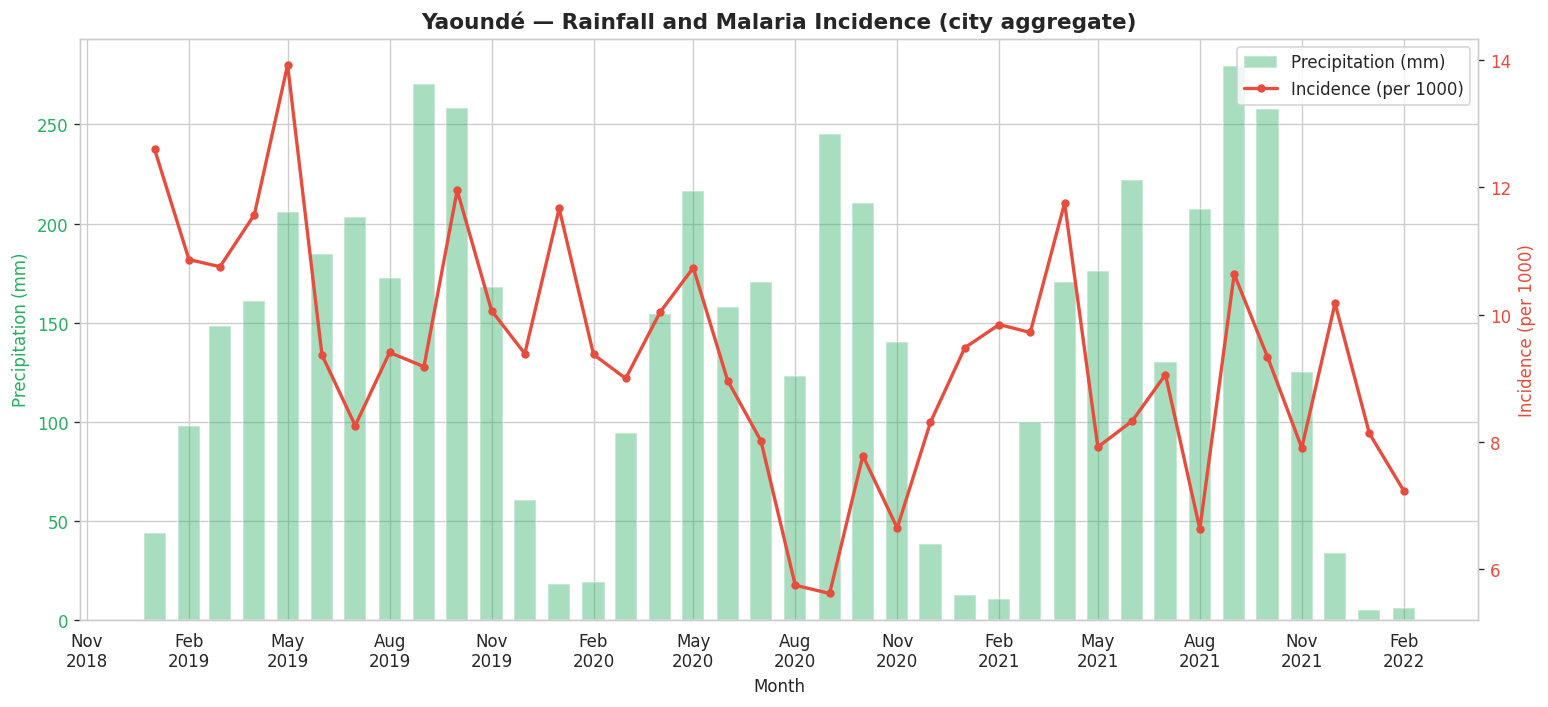

In [5]:
city = sub.groupby('date').agg(cases=('cases','sum'), pop=('p_totale','sum'),
                               precip=('Precipitation_mm','mean'),
                               temp=('Temperature_C','mean'),
                               humid=('Humidity_pct','mean')).reset_index()
city['incidence'] = city['cases']/city['pop']*1000

fig, ax1 = plt.subplots(figsize=(13,6))
ax1.bar(city.date, city.precip, width=20, color='#27ae60', alpha=0.4, label='Precipitation (mm)')
ax1.set_ylabel('Precipitation (mm)', color='#27ae60'); ax1.tick_params(axis='y', labelcolor='#27ae60')
ax2 = ax1.twinx()
ax2.plot(city.date, city.incidence, '-o', color='#e74c3c', ms=4, lw=2, label='Incidence (per 1000)')
ax2.set_ylabel('Incidence (per 1000)', color='#e74c3c'); ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.grid(False)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.set_xlabel('Month')
l1,lb1=ax1.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper right')
plt.title('Yaoundé — Rainfall and Malaria Incidence (city aggregate)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('yde_climate_malaria.png', bbox_inches='tight'); plt.show()


## 5 · Lagged correlation of incidence with climate

Computes the correlation between malaria incidence and each climate variable at
lags of 0 to 3 months, quantifying the delay that the lag features capture.


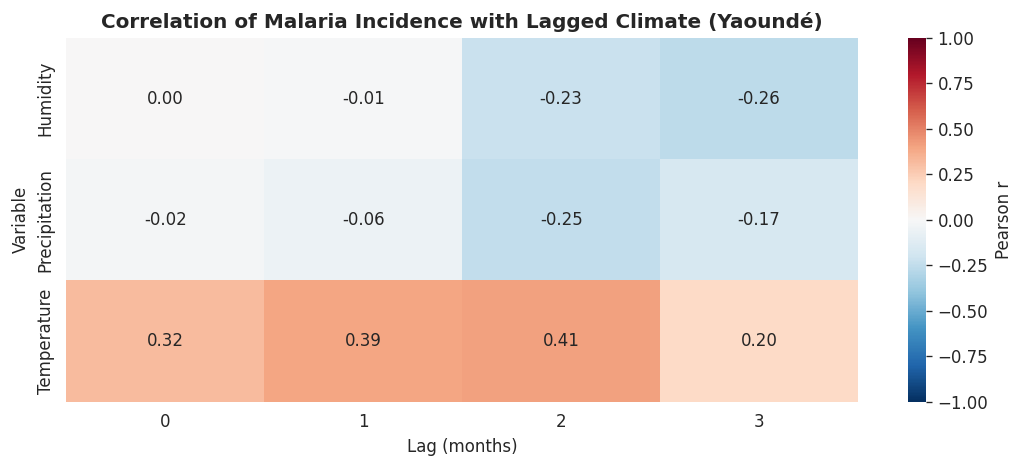

Lag (months),0,1,2,3
Variable,,,,
Humidity,0.00,-0.01,-0.23,-0.26
Precipitation,-0.02,-0.06,-0.25,-0.17
Temperature,0.32,0.39,0.41,0.20


Note: city-level n is small (38 months); correlations are indicative, not definitive.


In [6]:
# build city-level lagged correlations
c = city.sort_values('date').reset_index(drop=True)
lags = [0,1,2,3]; vars_ = {'precip':'Precipitation','temp':'Temperature','humid':'Humidity'}
rows=[]
for v,lab in vars_.items():
    for L in lags:
        corr = c['incidence'].corr(c[v].shift(L))
        rows.append({'Variable':lab,'Lag (months)':L,'Correlation':corr})
cor = pd.DataFrame(rows)
piv = cor.pivot(index='Variable', columns='Lag (months)', values='Correlation')
fig, ax = plt.subplots(figsize=(9,4))
sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'label':'Pearson r'})
ax.set_title('Correlation of Malaria Incidence with Lagged Climate (Yaoundé)', fontweight='bold')
plt.tight_layout(); plt.savefig('yde_lag_correlation.png', bbox_inches='tight'); plt.show()
display(piv.round(2))
print('Note: city-level n is small (38 months); correlations are indicative, not definitive.')


## 6 · Seasonal case cycle

The mean monthly incidence across years, exposing the seasonality of malaria that
parallels the rainfall climatology.


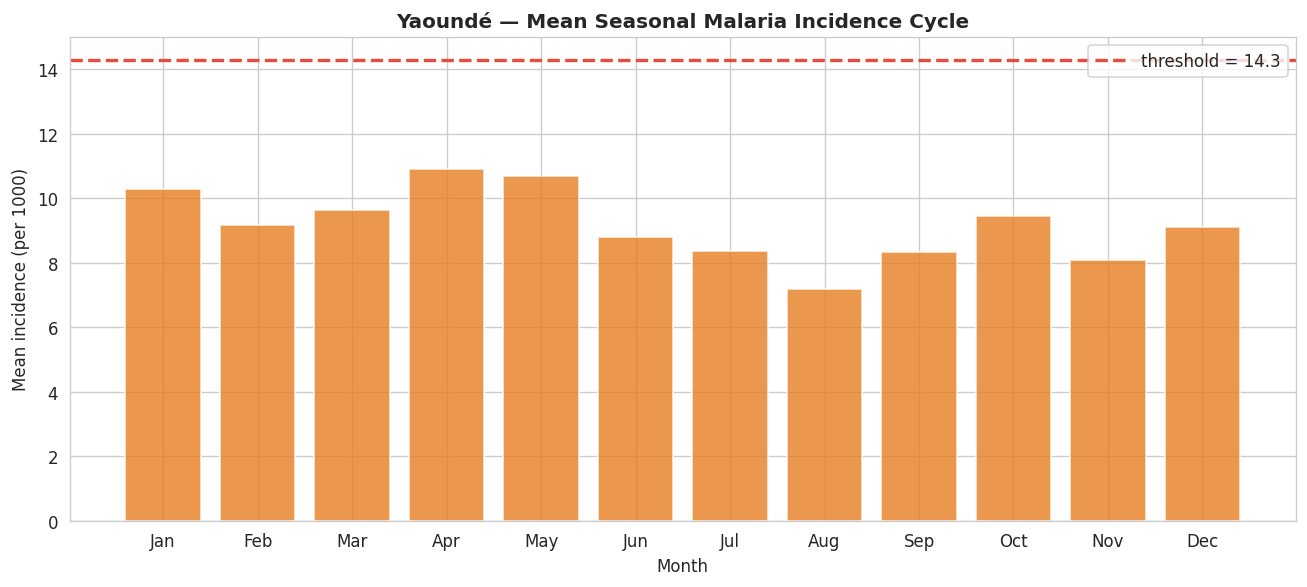

In [7]:
sub['month']=sub['date'].dt.month
season = sub.groupby('month').agg(incidence=('incidence_rate','mean')).reset_index()
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(11,5))
bars = ax.bar(season.month, season.incidence, color='#e67e22', alpha=0.8, edgecolor='white')
ax.axhline(THR, color='#e74c3c', ls='--', lw=2, label=f'threshold = {THR:.1f}')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names)
ax.set_ylabel('Mean incidence (per 1000)'); ax.set_xlabel('Month')
ax.set_title('Yaoundé — Mean Seasonal Malaria Incidence Cycle', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('yde_seasonal_cases.png', bbox_inches='tight'); plt.show()


## 7 · Summary

| File | Content |
|---|---|
| `yde_target_districts.png` | Cases and incidence per district |
| `yde_target_threshold.png` | Incidence with threshold, Low/High months |
| `yde_target_distribution.png` | Distribution + threshold (hist + boxplot) |
| `yde_climate_malaria.png` | Rainfall vs incidence overlay |
| `yde_lag_correlation.png` | Lagged climate–incidence correlation |
| `yde_seasonal_cases.png` | Mean seasonal incidence cycle |

Two findings for the thesis: Biyem Assi carries most of the High-risk months in
Yaoundé, and the regional threshold operates per district rather than on the city
aggregate; and malaria incidence relates to climate with a delay, supporting the
lagged climate features. The small city-level sample (38 months) means the lag
correlations are indicative.
